# Shopper Spectrum

## Notebook 5 — Customer Segmentation

In the previous notebook, we created RFM features that summarize each customer's purchasing behavior.

In this notebook, we will use the **K-Means clustering algorithm** to group customers with similar purchasing patterns. Finally, we will interpret each cluster and assign meaningful business labels such as **High-Value**, **Regular**, **Occasional**, and **At-Risk** customers.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

In [4]:
# Load RFM dataset
rfm = pd.read_csv("../data/rfm_table.csv")
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment
0,326,1,77183.60,1,1,5,115,11
1,2,7,4310.00,5,5,5,555,55
2,75,4,1797.24,2,4,4,244,24
3,19,1,1757.55,4,1,4,414,41
4,310,1,334.40,1,1,2,112,11


In [5]:
rfm.shape

(4338, 8)

In [6]:
# Plot style

plt.style.use("seaborn-v0_8")

sns.set_palette("Set2")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Select RFM Features

K-Means clustering uses numerical features to group similar customers.

Here, we will use the three RFM metrics:

- **Recency**
- **Frequency**
- **Monetary**

These features represent customer purchasing behaviour and will be used to build the clustering model.

In [7]:
# Select RFM features

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

rfm_features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


## Standardize the Features

The RFM metrics have different scales.

For example:

- Monetary values can be very large.
- Frequency is usually much smaller.
- Recency is measured in days.

If we use these values directly, the feature with the largest scale will dominate the clustering process.

To avoid this, we standardize all features using **StandardScaler** so that each feature contributes equally.

In [8]:
# Standardize the features

scaler = StandardScaler()

scaled_features = scaler.fit_transform(rfm_features)

In [9]:
# View standardized data

scaled_rfm = pd.DataFrame(
    scaled_features,
    columns=rfm_features.columns
)

scaled_rfm.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


## Determine the Optimal Number of Clusters

Before training the K-Means model, we need to choose an appropriate value of **K**, which represents the number of customer groups.

We will use the **Elbow Method** to compare different values of K and identify the point where adding more clusters provides only a small improvement.

In [10]:
# Calculate WCSS for different values of K

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

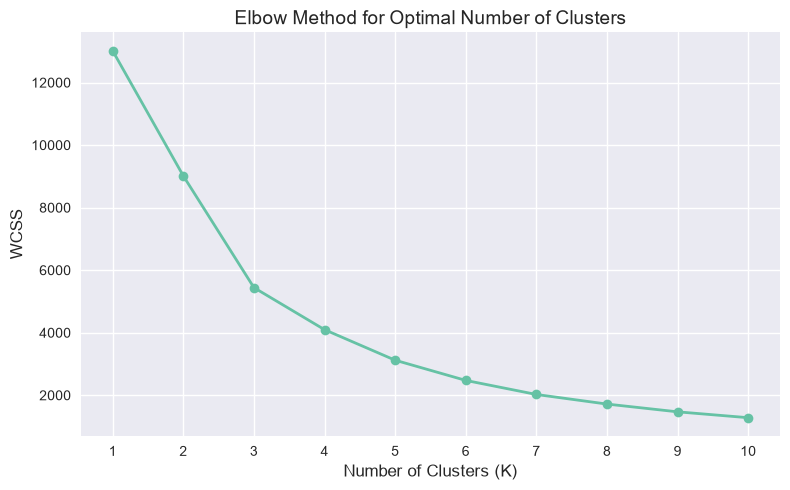

In [11]:
# Plot the Elbow Method

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker="o", linewidth=2)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.xticks(range(1, 11))

plt.tight_layout()
plt.show()

## Observation

The Elbow Method suggests a suitable value of **K** where the decrease in WCSS begins to slow down.

We will use this value in the next step and further validate it using the **Silhouette Score**.

## Evaluate Clustering with Silhouette Score

While the Elbow Method provides a visual estimate, the **Silhouette Score** measures how well the customers fit within their assigned clusters.

A higher Silhouette Score indicates better-defined and more distinct clusters.

In [12]:
# Calculate Silhouette Score for different values of K

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)

    silhouette_scores.append(score)

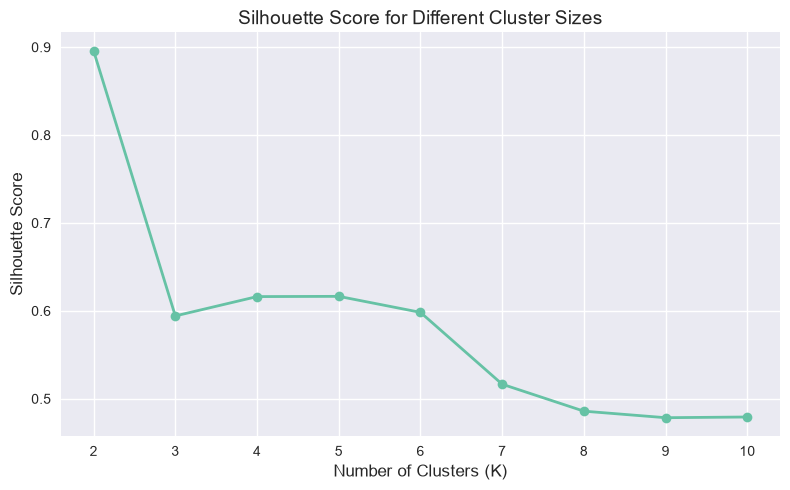

In [13]:
# Plot Silhouette Scores

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.title("Silhouette Score for Different Cluster Sizes")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

## Observation

Compare the results of the **Elbow Method** and the **Silhouette Score**.

If both methods suggest the same value of **K**, we can confidently use that number of clusters to build our final K-Means model.

## Train the K-Means Model

Based on the results of the Elbow Method and Silhouette Score, we can now train the final K-Means model.

In this project, we will use **4 clusters**, as it provides a good balance between model performance and business interpretation.

In [14]:
# Train the K-Means model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(scaled_features)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Cluster
0,326,1,77183.60,1,1,5,115,11,3
1,2,7,4310.00,5,5,5,555,55,0
2,75,4,1797.24,2,4,4,244,24,0
3,19,1,1757.55,4,1,4,414,41,0
4,310,1,334.40,1,1,2,112,11,1


## Explore Cluster Distribution

Before interpreting the clusters, let's see how many customers belong to each cluster.

In [15]:
# Number of customers in each cluster

rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

## Rename Customer Segments

The K-Means algorithm generates numeric cluster labels such as **0**, **1**, **2**, and **3**.

To make the results easier to understand, we will replace these numbers with business-friendly customer segment names.

In [16]:
# Rename customer segments

cluster_labels = {
    0: "Occasional",
    1: "At-Risk",
    2: "High-Value",
    3: "Regular"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_labels)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Cluster,Customer_Segment
0,326,1,77183.60,1,1,5,115,11,3,Regular
1,2,7,4310.00,5,5,5,555,55,0,Occasional
2,75,4,1797.24,2,4,4,244,24,0,Occasional
3,19,1,1757.55,4,1,4,414,41,0,Occasional
4,310,1,334.40,1,1,2,112,11,1,At-Risk


## Analyze Cluster Characteristics

To understand each cluster, we calculate the average **Recency**, **Frequency**, and **Monetary** values.

These averages help us interpret customer behaviour and assign meaningful business labels.

In [17]:
# Summary of each customer segment

cluster_summary = (
    rfm.groupby("Customer_Segment")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Customer_Segment,,,
At-Risk,248.08,1.55,478.85
High-Value,7.38,82.54,127187.96
Occasional,43.70,3.68,1353.63
Regular,15.50,22.33,12690.50


## Observation

Interpret the cluster averages carefully.

Generally:

- Lower **Recency** indicates more recent purchases.
- Higher **Frequency** indicates more frequent purchases.
- Higher **Monetary** indicates higher spending.

Based on these characteristics, we will assign meaningful customer segment names.

## Observation

The customer segments have now been assigned meaningful business labels.

These labels will be used throughout the rest of the project, including the Streamlit dashboard, where users can easily identify different customer groups.

## Visualize Customer Segments

Visualizations help us understand how customers are distributed across the identified segments.

We will first examine the number of customers in each segment and then compare the average RFM values across segments.

In [18]:
# Number of customers in each segment

segment_counts = rfm["Customer_Segment"].value_counts()

segment_counts

Customer_Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64

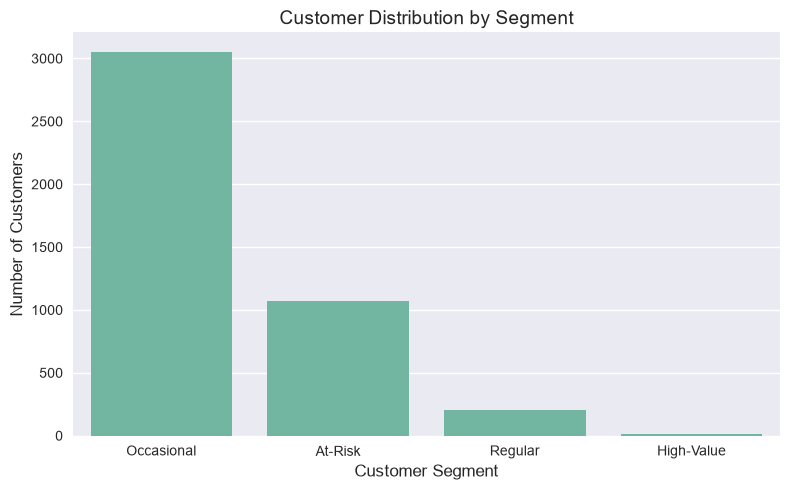

In [19]:
# Customer segment distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Customer_Segment",
    order=segment_counts.index
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Observation

The chart shows how customers are distributed across the identified segments.

This information can help businesses understand the size of each customer group and prioritize marketing strategies accordingly.

In [20]:
# Average RFM values by customer segment

cluster_summary

,Recency,Frequency,Monetary
Customer_Segment,,,
At-Risk,248.08,1.55,478.85
High-Value,7.38,82.54,127187.96
Occasional,43.70,3.68,1353.63
Regular,15.50,22.33,12690.50


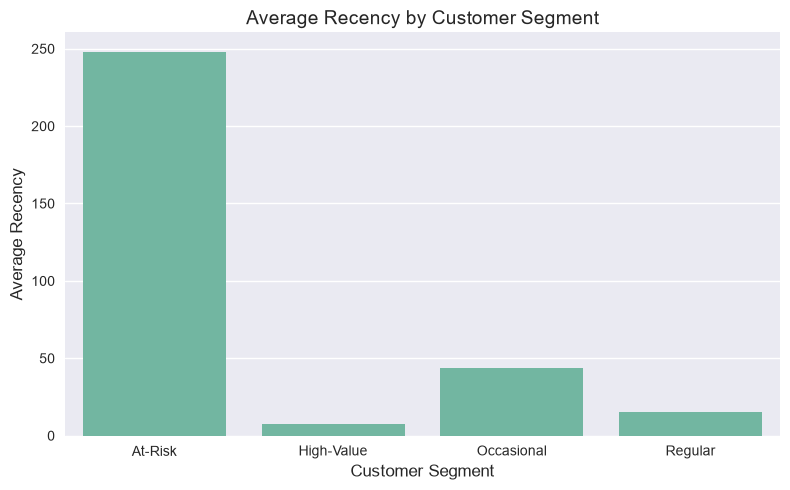

In [21]:
# Average Recency by customer segment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="Customer_Segment",
    y="Recency"
)

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency")

plt.tight_layout()
plt.show()

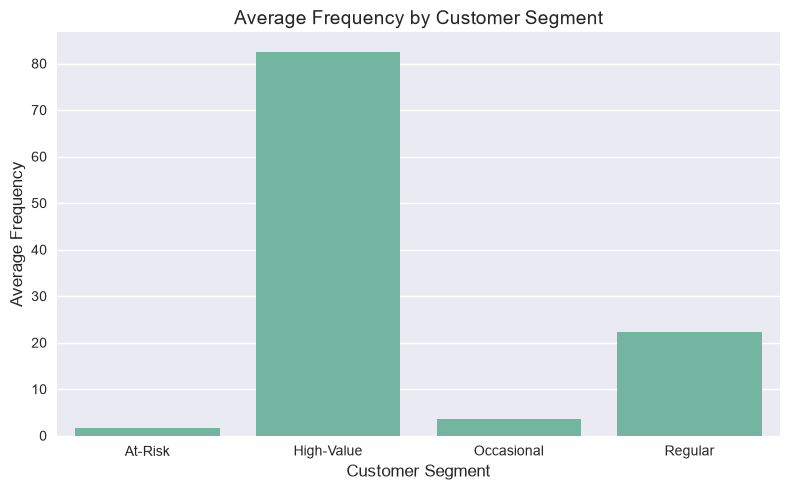

In [22]:
# Average Frequency by customer segment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="Customer_Segment",
    y="Frequency"
)

plt.title("Average Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Frequency")

plt.tight_layout()
plt.show()

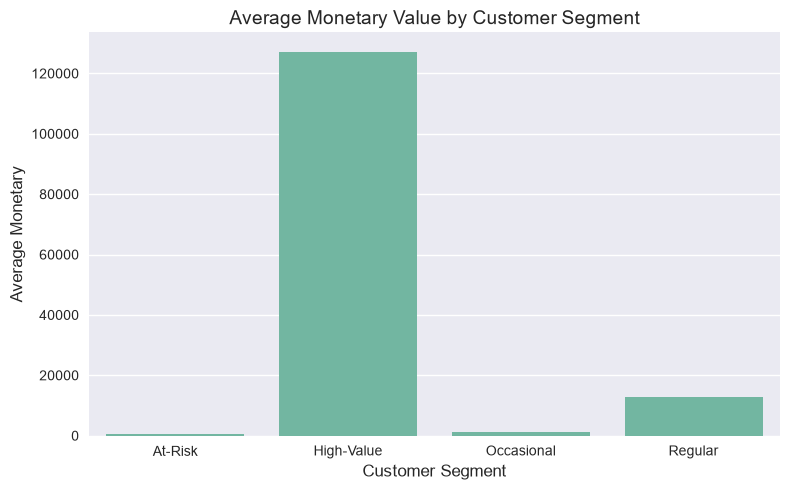

In [23]:
# Average Monetary by customer segment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="Customer_Segment",
    y="Monetary"
)

plt.title("Average Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary")

plt.tight_layout()
plt.show()

## Observation

The average RFM values clearly distinguish the customer segments.

- **High-Value** customers purchase frequently, spend the most, and have the most recent transactions.
- **Regular** customers purchase consistently but spend less than High-Value customers.
- **Occasional** customers purchase infrequently and have lower spending.
- **At-Risk** customers have not purchased for a long time and have the lowest purchasing activity.

These insights can help businesses design targeted marketing and customer retention strategies.

In [24]:
rfm["Cluster"] = kmeans.labels_

rfm["Customer_Segment"] = rfm["Cluster"].map({
    0: "Occasional",
    1: "At-Risk",
    2: "High-Value",
    3: "Regular"
})

## Save the Customer Segmentation Results

Finally, we will save the customer segmentation dataset and the trained model so they can be used later in the Streamlit dashboard.

In [25]:
# Save customer segmentation dataset

rfm.to_csv("../data/customer_segments.csv", index=False)

In [26]:
# Save the trained K-Means model

joblib.dump(kmeans, "../models/kmeans_model.pkl")

['../models/kmeans_model.pkl']

In [27]:
# Save the scaler

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

## Final Observation

In this notebook, we successfully segmented customers using the K-Means clustering algorithm.

Based on their purchasing behavior, customers were grouped into four business-friendly segments:

- High-Value
- Regular
- Occasional
- At-Risk

The trained model, scaler, and segmented dataset have been saved and will be used in the Streamlit dashboard for customer segmentation and prediction.